In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.models.apogee import Spectrum
from ugdatalab.methods.cannon import CannonModel
from ugdatalab.methods.cannon_likelihood import CannonLabelLikelihood
from ugdatalab.methods.bayesian.mcmc import nuts_sample
from ugdatalab.plotters.bayesian import plot_corner, plot_trace
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone

import plotters

In [2]:
# Load trained Cannon model
model_data = np.load("cannon_model.npz", allow_pickle=True)
model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)
print(f"Cannon model loaded: chi2_r = {model.chi2_r:.3f}")

Cannon model loaded: chi2_r = 1.060


## Problem 12 — MCMC Label Fitting of the Mystery Spectrum

### Read and normalize the mystery spectrum

In [3]:
mystery_path = Path("../../course_materials_sp2026/labs/lab_2/mystery_spec_wiped.fits")
continuum_path = Path("continuum_wavelengths.npz")

mystery = Spectrum(mystery_path, continuum_path)
flux_norm = mystery.flux[0]
error_norm = mystery.error[0]

valid = np.isfinite(flux_norm) & (error_norm < np.inf)
print(f"Mystery spectrum: {np.sum(valid)} valid pixels out of {len(flux_norm)}")

Mystery spectrum: 7371 valid pixels out of 8575


### Prior statement

We place weakly informative Normal priors on each label centered on the training-set means, with width $= 2\sigma$ (training-set standard deviations):

$$\ell_i \sim \mathcal{N}(\mu_i, (2\sigma_i)^2)$$

This allows the posterior to be dominated by the spectral data while keeping the sampler near the training-set support.

In [4]:
prior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Prior mean (μ)": model.label_means,
    "Prior width (2σ)": 2 * model.label_stds,
})
prior_df

,Label,Prior mean (μ),Prior width (2σ)
0,TEFF,4587.693304,763.944243
1,LOGG,2.373109,1.387430
2,FE_H,-0.108870,0.530565
3,MG_FE,0.097610,0.228003
4,SI_FE,0.048905,0.165381


### MCMC fit

In [5]:
lk = CannonLabelLikelihood(
    x=model.wavelength,
    y=flux_norm,
    y_err=error_norm,
    model=model,
)
result = nuts_sample(lk, n_steps=2000, n_burn=1000, seed=42)
print(f"MCMC chi2_r: {result.chi2_r:.3f}")
print(f"Posterior median labels: {result.theta}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [TEFF, LOGG, FE_H, MG_FE, SI_FE]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


MCMC chi2_r: nan
Posterior median labels: [ 4.54320664e+03  1.95409917e+00 -6.21057681e-01  3.00714941e-01
  2.16298957e-01]


### Corner plot

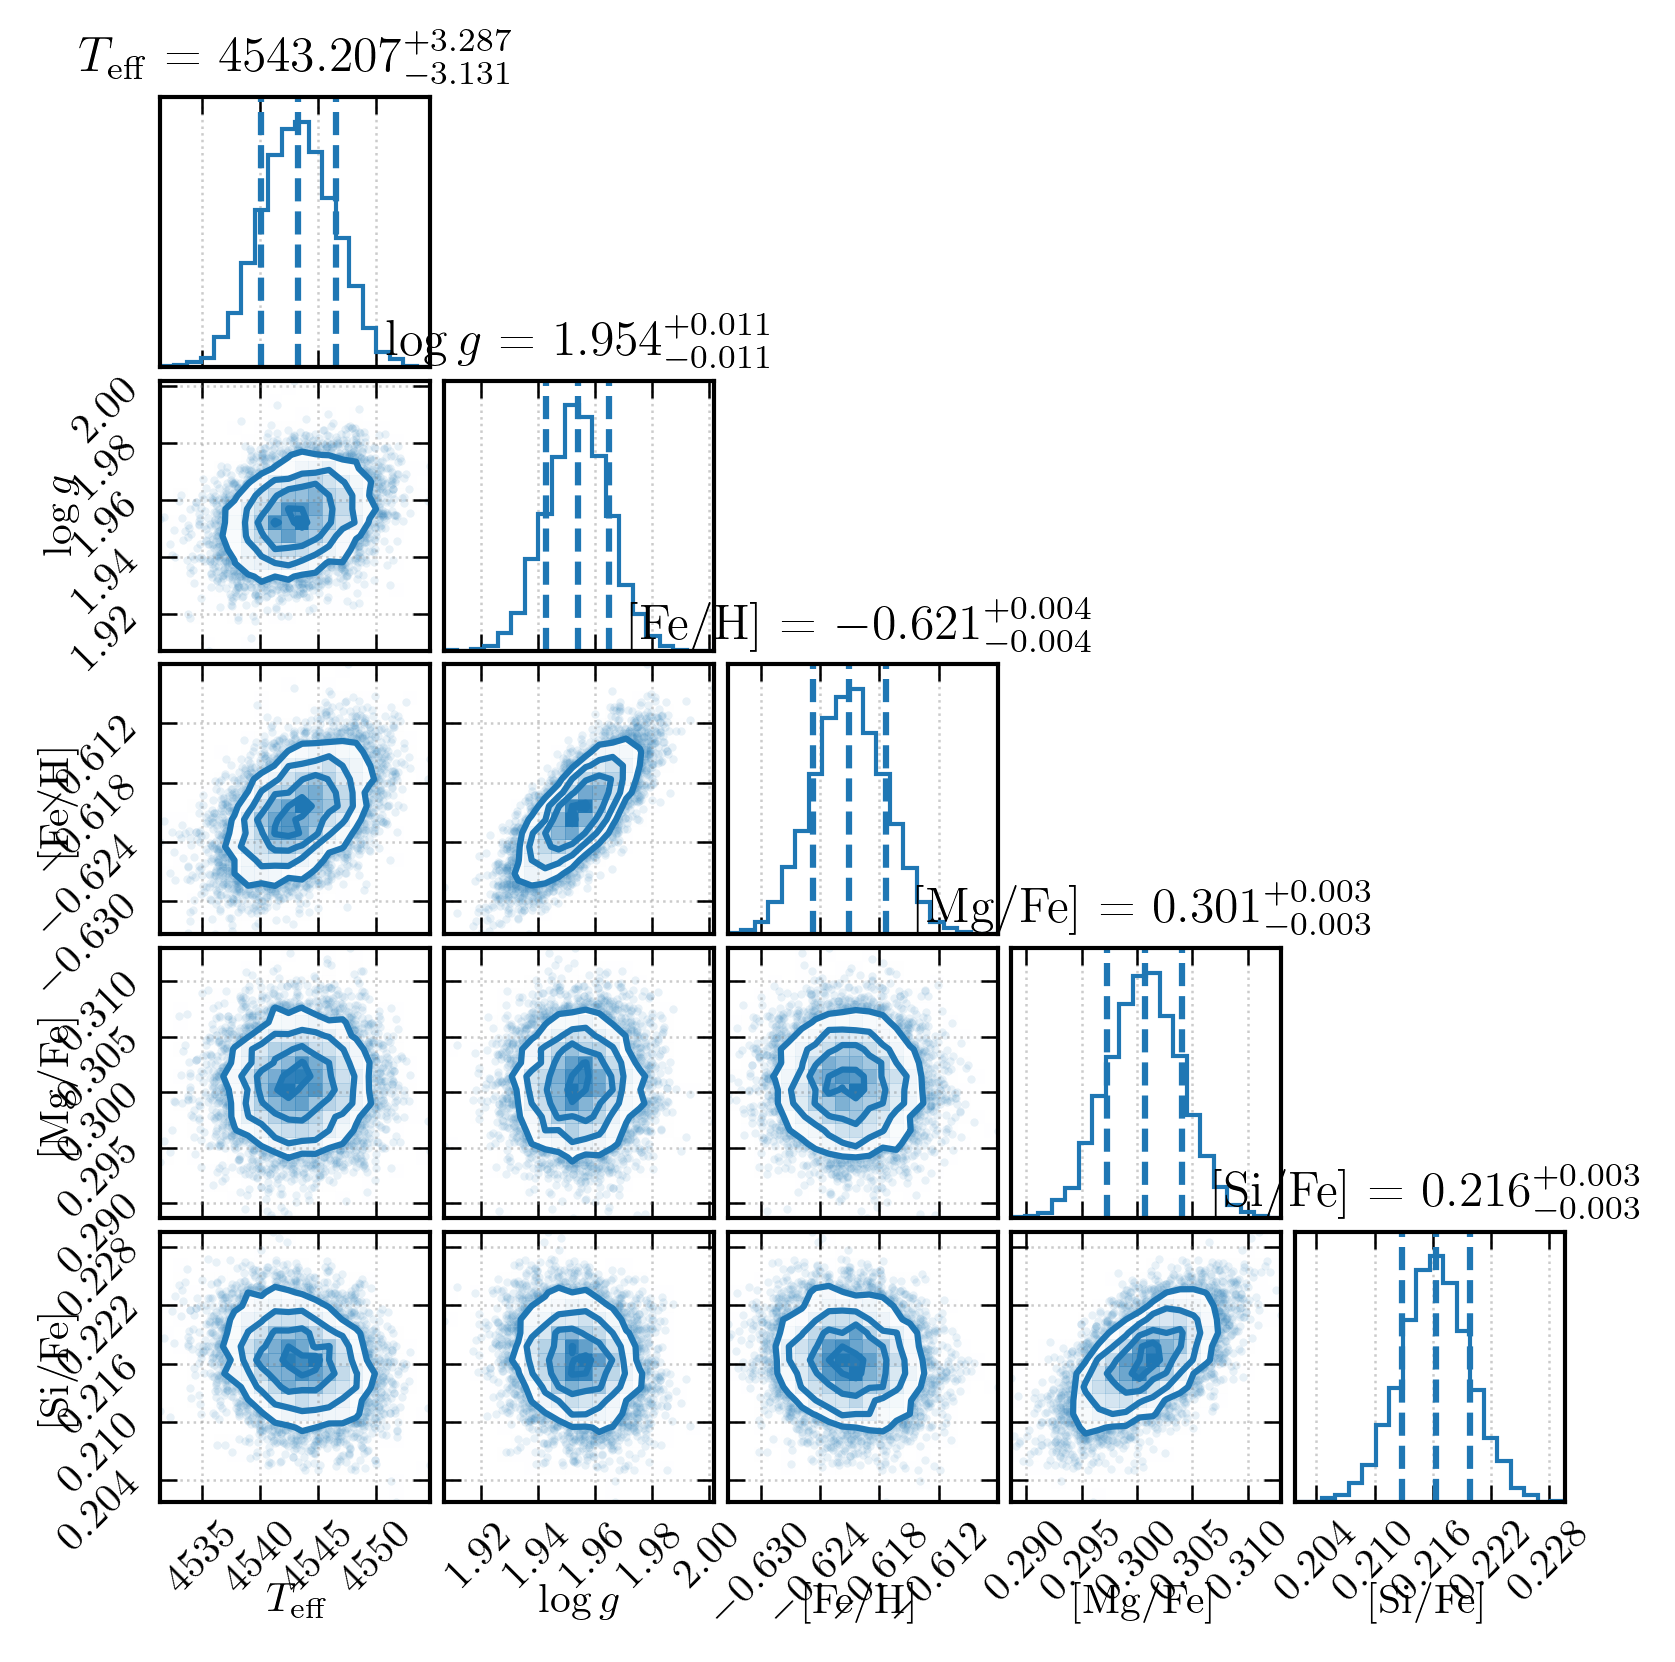

In [6]:
plot_corner(result)
plt.show()

### Trace plot

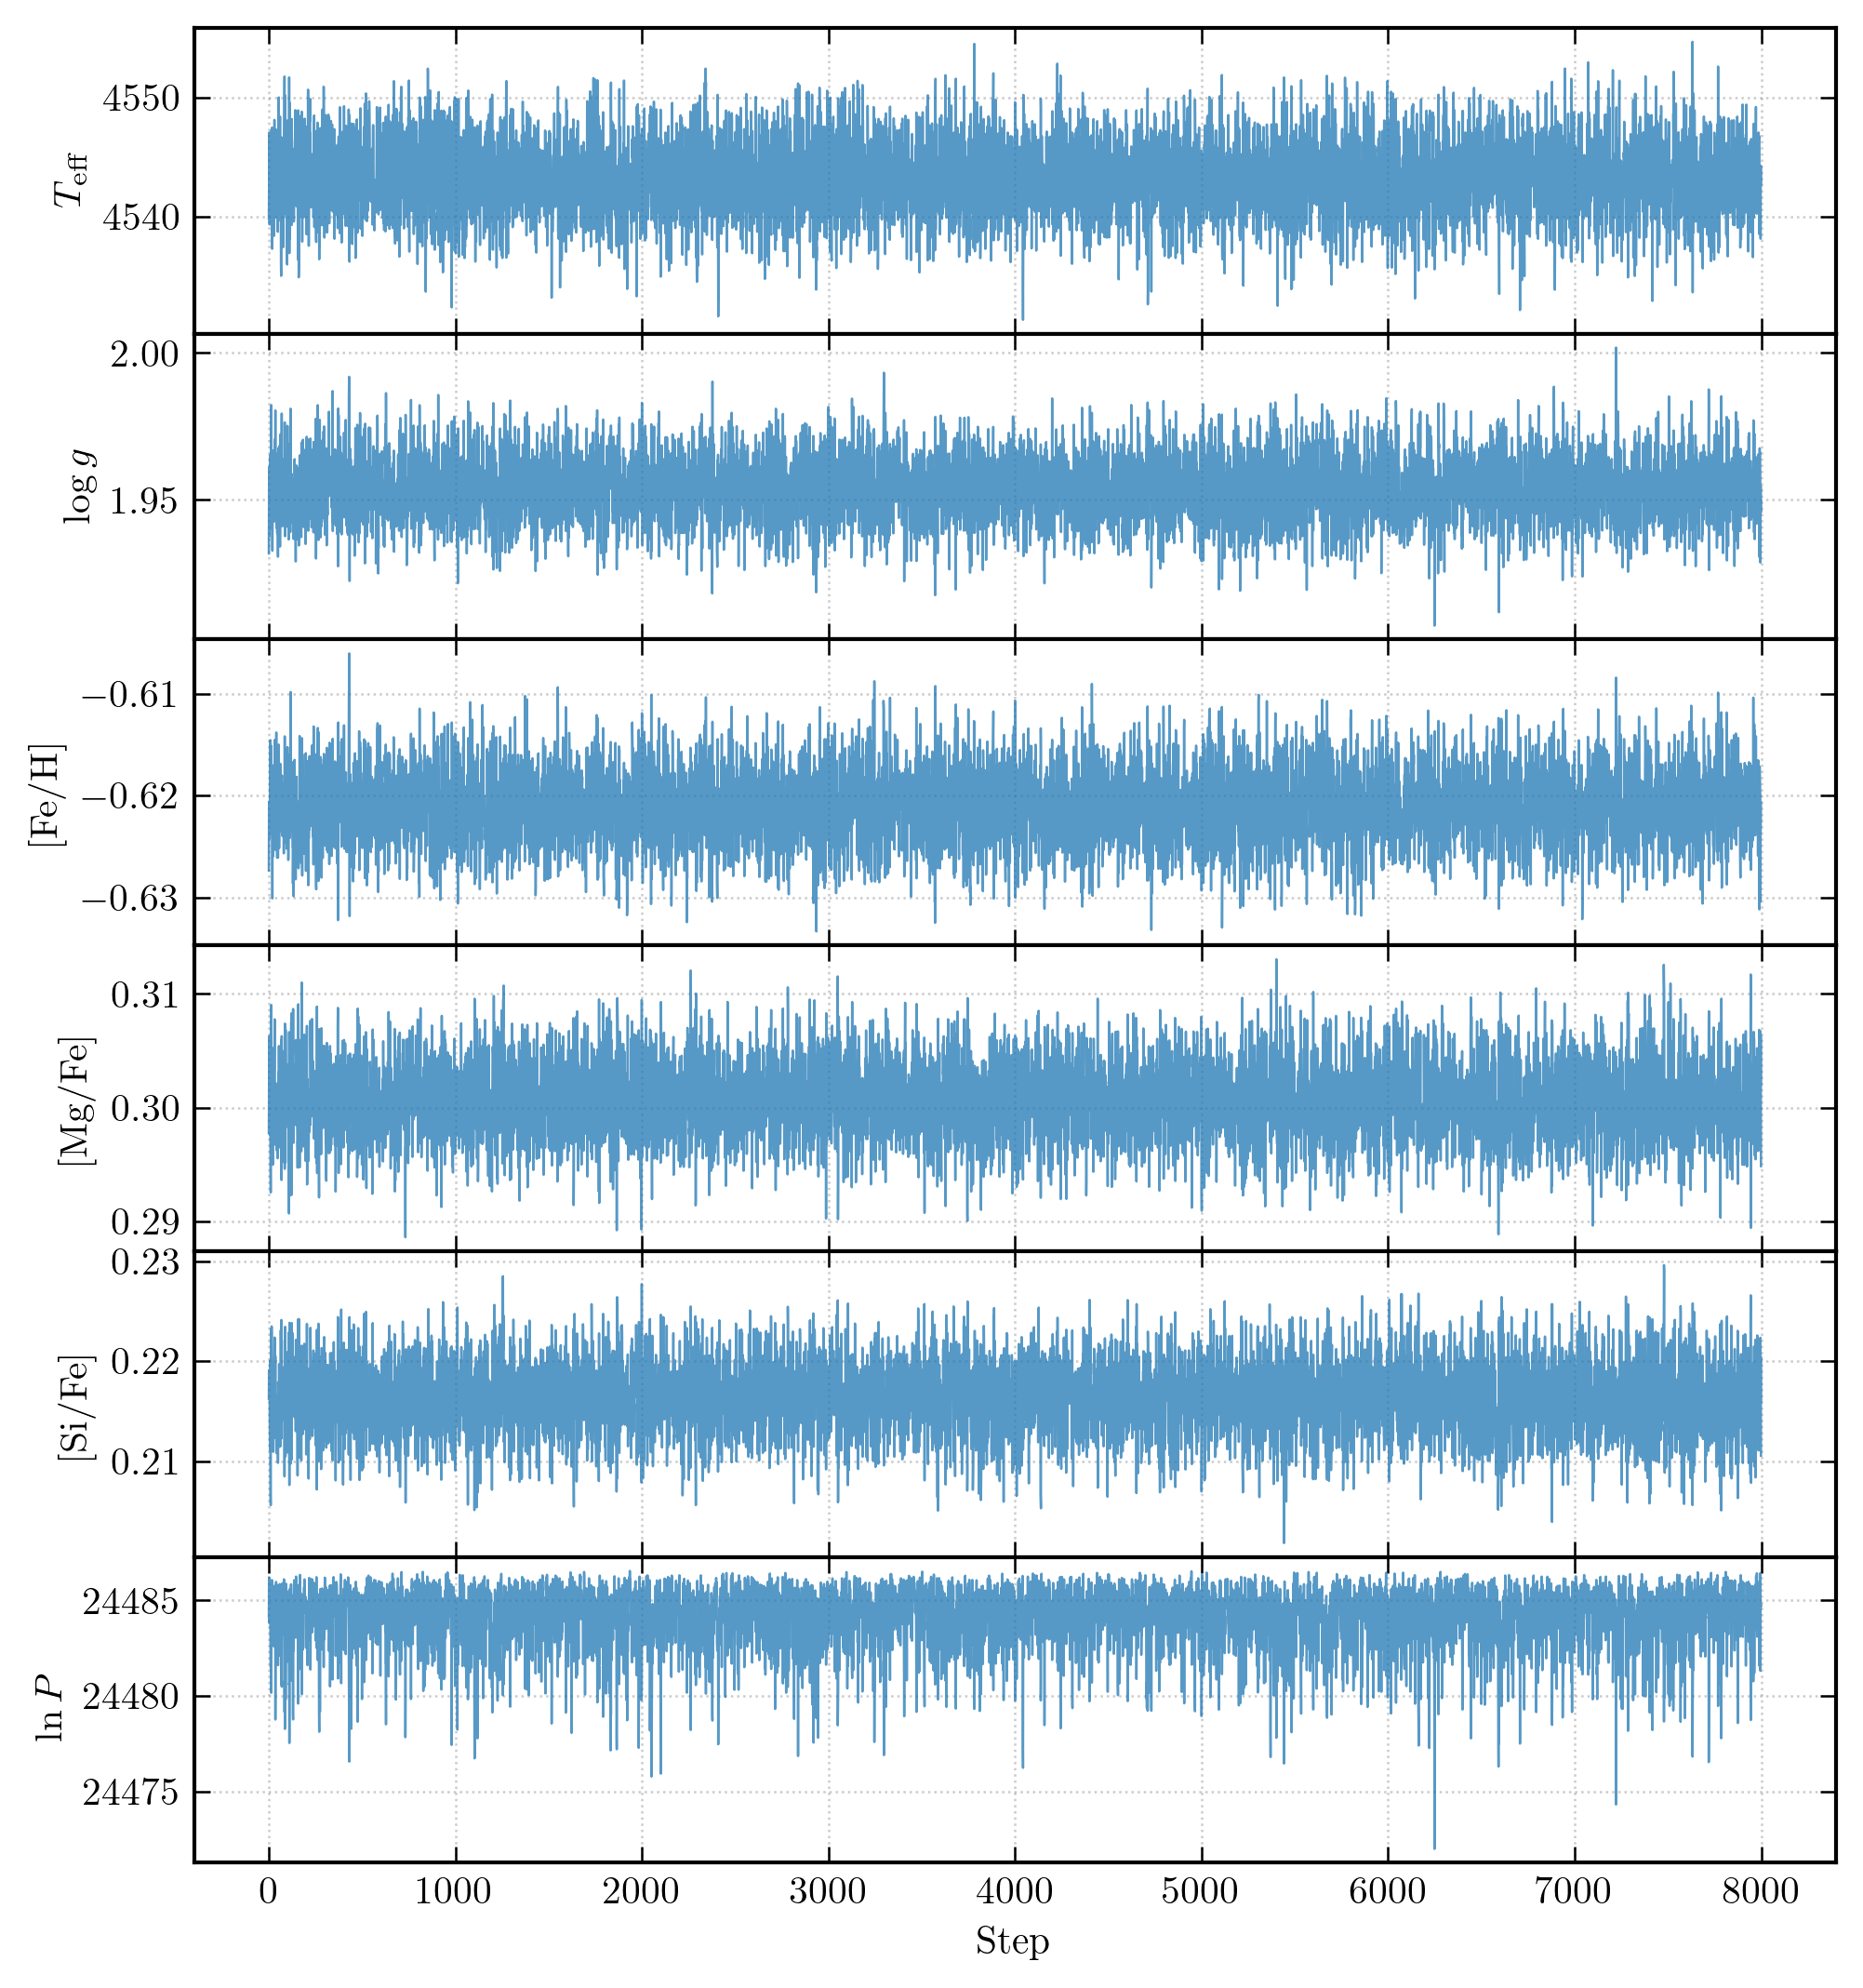

In [7]:
plot_trace(result)
plt.show()

### Posterior summary

In [8]:
medians = np.median(result.samples, axis=0)
lo = np.percentile(result.samples, 16, axis=0)
hi = np.percentile(result.samples, 84, axis=0)

posterior_df = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Median": medians,
    "16th pct": lo,
    "84th pct": hi,
    "σ (68% CI half-width)": (hi - lo) / 2,
})
posterior_df

,Label,Median,16th pct,84th pct,σ (68% CI half-width)
0,TEFF,4543.206642,4540.075970,4546.493735,3.208882
1,LOGG,1.954099,1.942944,1.964861,0.010959
2,FE_H,-0.621058,-0.624740,-0.617350,0.003695
3,MG_FE,0.300715,0.297308,0.304026,0.003359
4,SI_FE,0.216299,0.212826,0.219777,0.003475


### Uncertainty discussion

The formal MCMC uncertainties are likely much smaller than the cross-validation scatter from Problem 9 (e.g., $\sim 30$ K in $T_{\rm eff}$ vs CV scatter of $\sim 30$–$50$ K, and $\sim 0.01$ dex in $[\mathrm{Fe/H}]$ vs CV scatter of $\sim 0.02$–$0.05$ dex). They are also likely smaller than typical ASPCAP errors ($\sim 100$ K for $T_{\rm eff}$, $\sim 0.1$ dex for $\log g$).

This underestimation arises because the MCMC treats each pixel as independent, but in reality:
1. **Continuum systematics**: residual normalization errors correlate across many pixels within each chip.
2. **Line blending**: adjacent pixels in absorption features are physically correlated through the line profile.
3. **Model inadequacy**: the 2nd-order polynomial is an approximation — the per-pixel scatter $s_\lambda^2$ absorbs some of this, but not pixel-to-pixel correlations in the model error.

The CV scatter from Problem 9 provides a more realistic estimate of the true label uncertainty, as it captures all these systematic effects.

## Problem 13 — Metallicity Sequence

We generate synthetic spectra at fixed $T_{\rm eff} = 4800$ K, $\log g = 2.5$, $[\mathrm{Mg/Fe}] = 0$, $[\mathrm{Si/Fe}] = 0$, varying $[\mathrm{Fe/H}]$ from $-1$ to $+0.5$ in 0.25 dex steps. This isolates the effect of metallicity on spectral features.

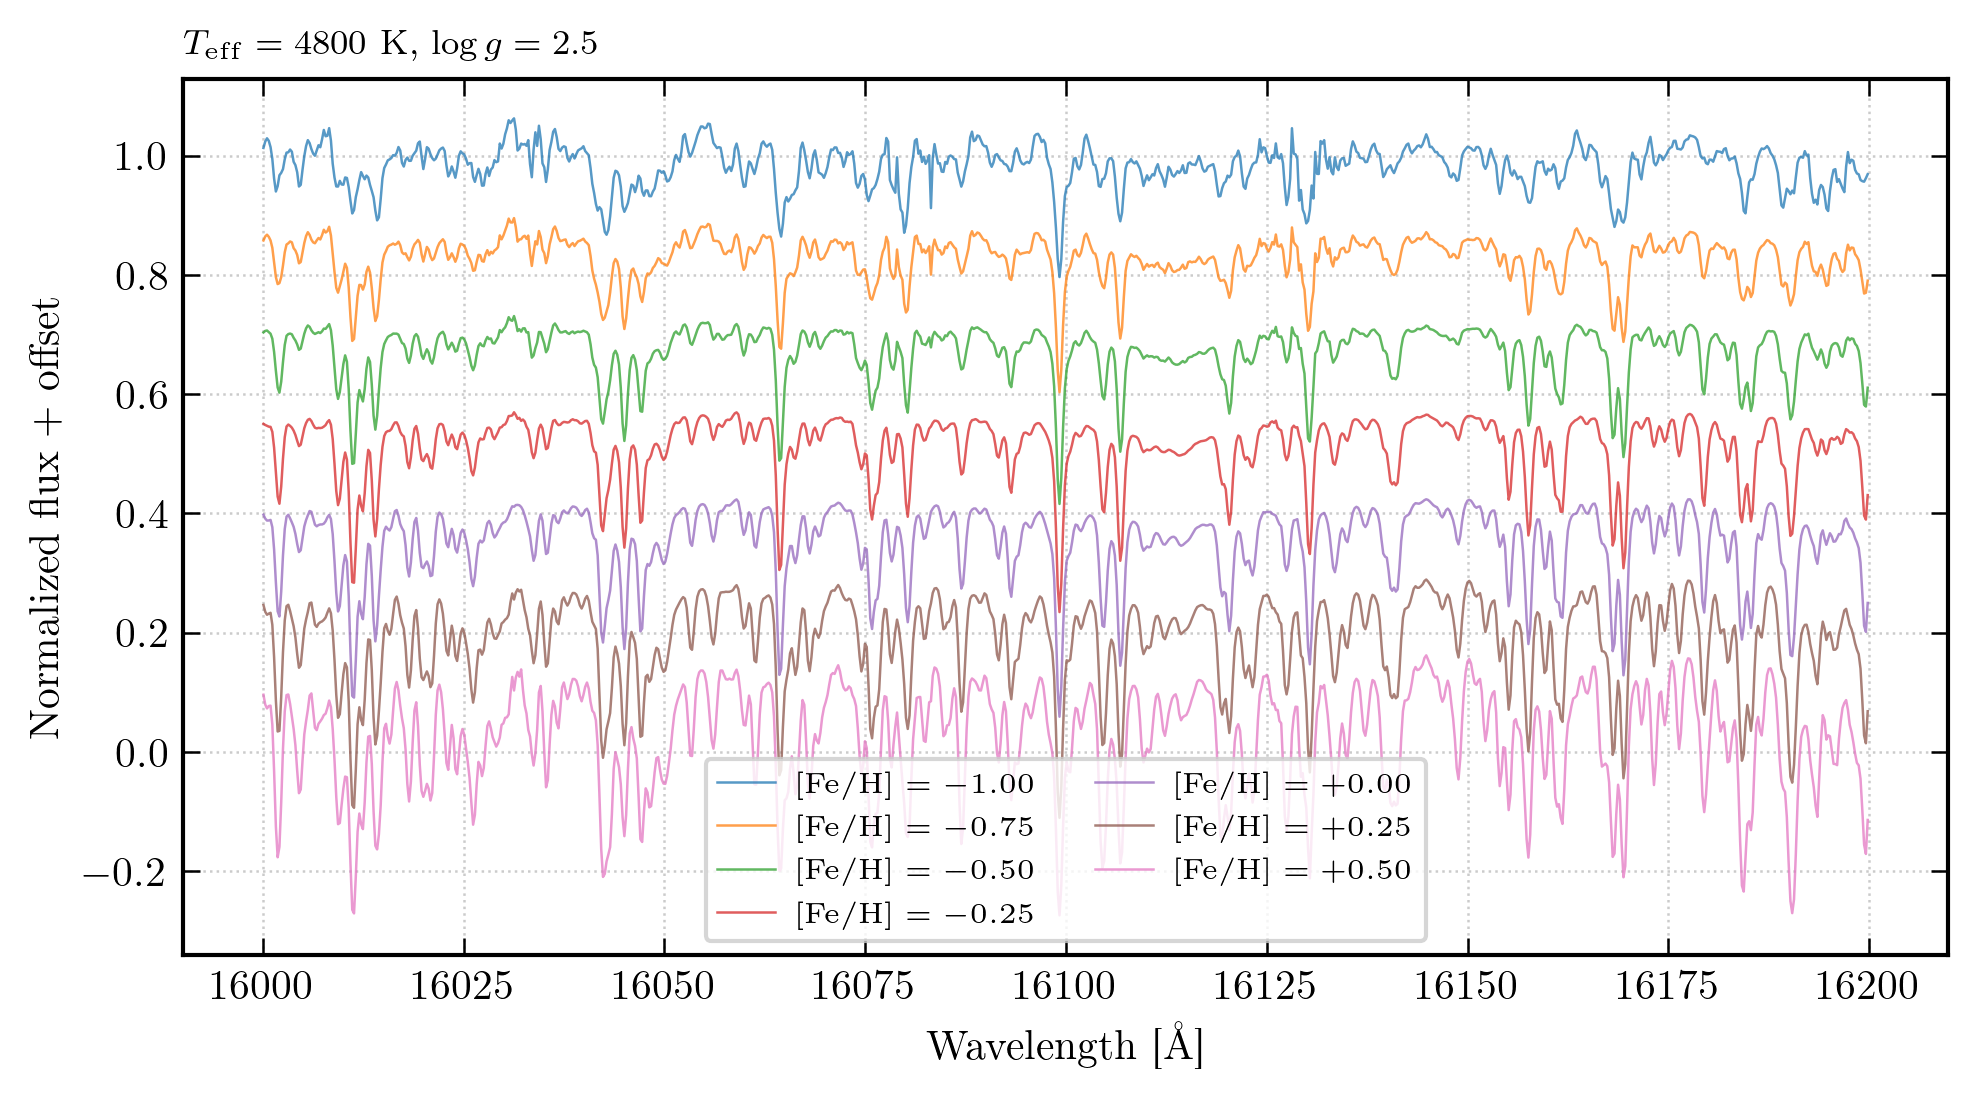

In [9]:
feh_values = np.arange(-1.0, 0.75, 0.25)

ax = plotters.plot_metallicity_sequence(model, feh_values)
plt.show()

## Problem 14 — RGB Evolution

We extract a $(T_{\rm eff}, \log g)$ track along the red giant branch from a MIST isochrone at $[\mathrm{Fe/H}] = 0$, spanning $\log g = 3.5$ to $0.5$. Synthetic spectra along this track show how the spectrum changes as a star ascends the RGB.

RGB track: 7 points
       Teff     logg
4910.941326 3.481357
4658.709572 2.420912
4590.229799 2.354966
4409.297011 2.045381
4220.135522 1.760261
3888.982949 1.351574
3651.801979 0.871492


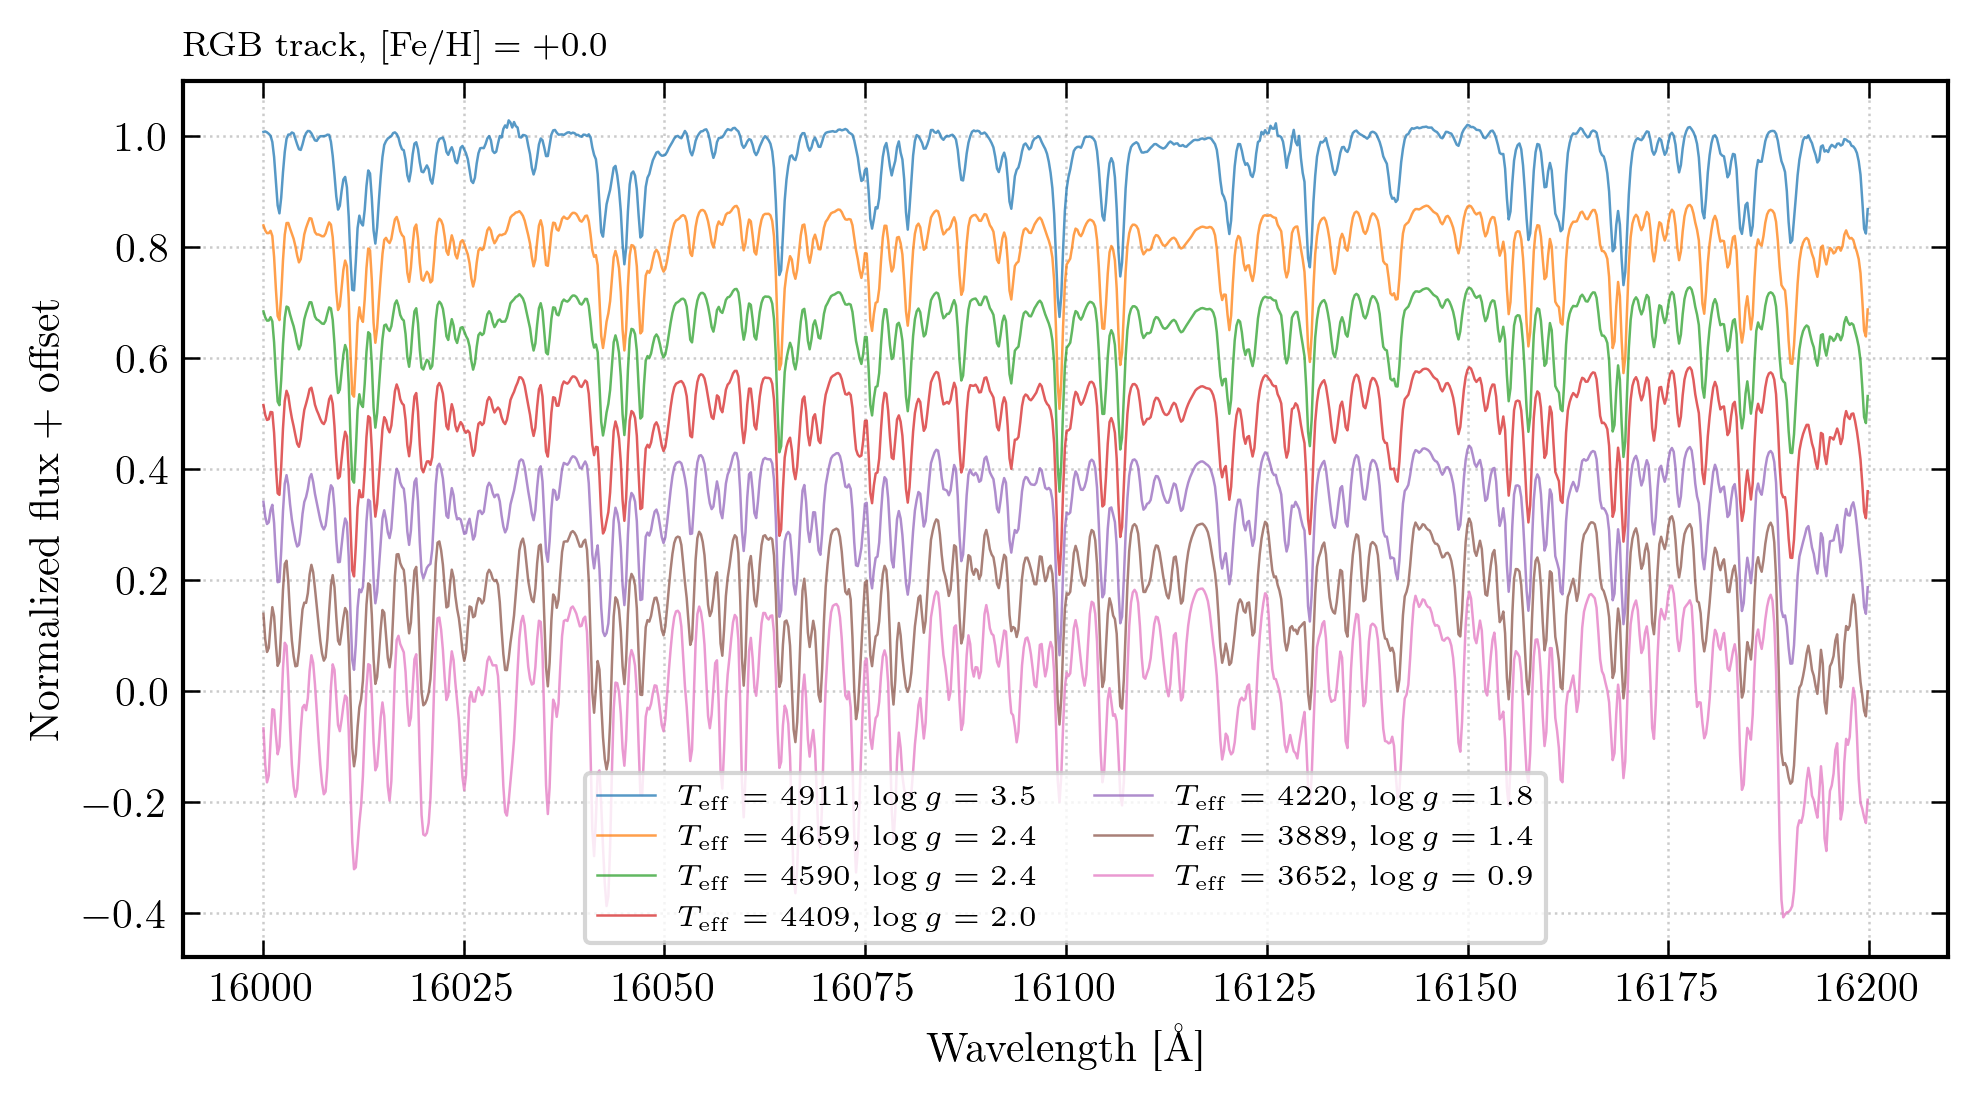

In [10]:
iso_solar = _get_mist_isochrone(6.0, 0.0)

# Extract RGB track: logg decreasing from 3.5 to 0.5
rgb_mask = (iso_solar["logg"] >= 0.5) & (iso_solar["logg"] <= 3.5) & (iso_solar["Teff"] < 5500)
rgb = iso_solar[rgb_mask].sort_values("logg", ascending=False)

# Sample ~7 points along the RGB
n_points = min(7, len(rgb))
step = max(1, len(rgb) // n_points)
rgb_sample = rgb.iloc[::step][:n_points]

print(f"RGB track: {len(rgb_sample)} points")
print(rgb_sample[["Teff", "logg"]].to_string(index=False))

ax = plotters.plot_rgb_evolution(
    model, rgb_sample["Teff"].values, rgb_sample["logg"].values,
)
plt.show()

Comparing the metallicity sequence (Problem 13) to the RGB evolution (Problem 14): both change the absorption line depths, but in distinguishable ways. Metallicity primarily affects Fe-line strengths (and to a lesser extent Mg/Si lines), while ascending the RGB (decreasing $T_{\rm eff}$ and $\log g$) changes the overall spectral morphology — molecular features strengthen, the ionization balance shifts, and pressure-broadened lines narrow at lower surface gravity.

The key question is: how do we distinguish a cool, low-gravity star from a warmer, higher-gravity, more metal-rich star? The answer is that the *pattern* of line strengths differs — Mg and Si lines respond differently to temperature vs. abundance changes, and molecular features (e.g., CO, OH) are strongly temperature-sensitive but weakly metallicity-sensitive. The Cannon captures these differential sensitivities through the per-pixel polynomial coefficients.

## Problem 15 — Unresolved Binaries

An unresolved binary produces a composite spectrum — the flux-weighted sum of two stellar spectra. When the Cannon fits this composite with a single-star model, it returns intermediate "effective" labels:

- **$T_{\rm eff}$**: biased high — the secondary (typically cooler) adds red flux, but the combined SED is bluer than the primary alone, pushing the fit toward higher temperature.
- **$\log g$**: may be biased depending on the luminosity ratio — the secondary contributes flux at different line depths.
- **Abundances**: diluted — absorption features from the primary are partially filled in by the secondary's continuum, making lines appear shallower and abundances appear lower.

These biases are discussed in El-Badry et al. (2018), who show that unresolved binaries can mimic metal-poor single stars. Possible mitigations:
1. **Two-component model**: fit a composite spectrum with two sets of labels and a flux ratio.
2. **Binary flagging**: identify candidate binaries via large radial velocity scatter across visits (`vhelio_avg` dispersion) or anomalous position in the Kiel diagram.
3. **Spectral disentangling**: use multi-epoch spectra to separate the two components.